# Deng control-volume reconstruction on rectangular bulk meshes

This notebook applies the Deng-Ginting-McCaskill local post-processing to the same no-fracture manufactured test case used in the triangular notebook. The rectangular mesh is obtained by reading the `Omega_ex1_ref.msh` files used by the nonconforming fracture notebook and projecting their thin hexahedral slab cells onto the `(x,y)` plane. A true two-dimensional quadrilateral DOLFINx mesh is then rebuilt from this projection, so both the CG solve and the Deng reconstruction use the same 2D `Q_1` basis and the standard median-dual subdivision by cell centroid and edge midpoints.


In [11]:
# ============================================================
# Configuration and imports
# ============================================================
from mpi4py import MPI
import numpy as np
import math
import time
import pathlib
import basix
import basix.ufl
import matplotlib.pyplot as plt
from tqdm import tqdm

from dolfinx import mesh, fem
from dolfinx.fem import petsc
try:
    from dolfinx.io import gmsh as gmshio
except ImportError:
    from dolfinx.io import gmshio
import ufl

order = 1

RUN_CONVERGENCE = True
CONV_REFS = [2, 3, 4, 5, 6]
REF_DEMO = 5

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})


In [12]:
# ============================================================
# Exact solution and mesh paths
# ============================================================
def mesh_path_for_ref(ref):
    name = f"Omega_ex1_{ref}.msh"
    candidates = [
        pathlib.Path.cwd() / name,
        pathlib.Path.cwd() / "fenicsx/code/fracture problem" / name,
        pathlib.Path.cwd() / "fenicsx/code" / name,
        pathlib.Path("fenicsx/code/fracture problem") / name,
        pathlib.Path("fenicsx/code") / name,
    ]
    for p in candidates:
        if p.exists():
            return str(p)
    raise FileNotFoundError(f"Could not find {name}; tried: " + ", ".join(str(p) for p in candidates))


def exact_p(points):
    pts = np.asarray(points, dtype=float)
    return 0.5 * pts[:, 0] * pts[:, 1] ** 2


def exact_grad_p(points):
    pts = np.asarray(points, dtype=float)
    g = np.zeros((len(pts), 2), dtype=float)
    g[:, 0] = 0.5 * pts[:, 1] ** 2
    g[:, 1] = pts[:, 0] * pts[:, 1]
    return g


def exact_q(points):
    pts = np.asarray(points, dtype=float)
    k = 2.0 * pts[:, 0] + 1.0
    q = np.zeros((len(pts), 2), dtype=float)
    q[:, 0] = -k * 0.5 * pts[:, 1] ** 2
    q[:, 1] = -k * pts[:, 0] * pts[:, 1]
    return q


def f_exact_xy(x, y):
    return -y**2 - 2.0 * x**2 - x


def f_exact_points(points):
    pts = np.asarray(points, dtype=float)
    return f_exact_xy(pts[:, 0], pts[:, 1])


def p_exact_callable(x):
    return 0.5 * x[0] * x[1] ** 2


def k_callable_xy(points):
    pts = np.asarray(points, dtype=float)
    return 2.0 * pts[:, 0] + 1.0


In [13]:
# ============================================================
# Read the thin 3D slab and rebuild a true 2D quadrilateral mesh
# ============================================================
def slab_to_2d_quad_mesh(filename, comm=MPI.COMM_WORLD):
    slab = gmshio.read_from_msh(filename, comm, 0, gdim=3)[0]
    tdim = slab.topology.dim
    slab.topology.create_connectivity(tdim, 0)
    c2v = slab.topology.connectivity(tdim, 0)
    x3 = slab.geometry.x
    num_slab_cells = slab.topology.index_map(tdim).size_local

    vertex_key_to_id = {}
    points_2d = []
    cells_2d = []
    seen_cells = set()

    def key_xy(xy):
        return tuple(np.round(np.asarray(xy, dtype=float), 12))

    def get_vertex_id(xy):
        key = key_xy(xy)
        if key not in vertex_key_to_id:
            vertex_key_to_id[key] = len(points_2d)
            points_2d.append(np.asarray(xy, dtype=float))
        return vertex_key_to_id[key]

    for ci in range(num_slab_cells):
        verts = np.asarray(c2v.links(ci), dtype=np.int32)
        xy_all = x3[verts, :2]
        x0, x1 = xy_all[:, 0].min(), xy_all[:, 0].max()
        y0, y1 = xy_all[:, 1].min(), xy_all[:, 1].max()

        corners = np.array([
            [x0, y0],
            [x1, y0],
            [x0, y1],
            [x1, y1],
        ], dtype=float)
        cell_key = tuple(key_xy(corner) for corner in corners)
        if cell_key in seen_cells:
            continue
        seen_cells.add(cell_key)

        cells_2d.append([get_vertex_id(corner) for corner in corners])

    points_2d = np.asarray(points_2d, dtype=np.float64)
    cells_2d = np.asarray(cells_2d, dtype=np.int64)

    coord_el = basix.ufl.element("Lagrange", "quadrilateral", 1, shape=(2,))
    domain = ufl.Mesh(coord_el)
    omega2d = mesh.create_mesh(comm, cells_2d, domain, points_2d)

    meta = {
        "source_mesh_file": filename,
        "source_slab_cells": num_slab_cells,
        "quad_cells": int(len(cells_2d)),
        "quad_vertices": int(len(points_2d)),
    }
    return omega2d, meta


# ============================================================
# CG solve on the rebuilt 2D quadrilateral mesh
# ============================================================
def solve_cg_rect(ref):
    filename = mesh_path_for_ref(ref)
    omega, mesh_meta = slab_to_2d_quad_mesh(filename, MPI.COMM_WORLD)
    tdim = omega.topology.dim
    fdim = tdim - 1

    coords = omega.geometry.x
    xs = np.unique(np.round(coords[:, 0], 12))
    ys = np.unique(np.round(coords[:, 1], 12))
    hx_vals = np.diff(xs)
    hy_vals = np.diff(ys)
    hx = float(np.min(hx_vals[hx_vals > 0.0]))
    hy = float(np.min(hy_vals[hy_vals > 0.0]))
    h = max(hx, hy)

    V = fem.functionspace(omega, ("Lagrange", order))
    phi = ufl.TestFunction(V)
    dp = ufl.TrialFunction(V)
    x = ufl.SpatialCoordinate(omega)

    k = 2.0 * x[0] + 1.0
    f_m = f_exact_xy(x[0], x[1])
    a = k * ufl.dot(ufl.grad(dp), ufl.grad(phi)) * ufl.dx
    L = f_m * phi * ufl.dx

    xmin, xmax = coords[:, 0].min(), coords[:, 0].max()
    ymin, ymax = coords[:, 1].min(), coords[:, 1].max()
    tol = 1e-10 * max(xmax - xmin, ymax - ymin)

    bottom = mesh.locate_entities_boundary(omega, fdim, lambda x: np.isclose(x[1], ymin, atol=tol))
    top = mesh.locate_entities_boundary(omega, fdim, lambda x: np.isclose(x[1], ymax, atol=tol))
    idx = np.concatenate([bottom, top]).astype(np.int32)
    val = np.concatenate([np.full(len(bottom), 10, np.int32), np.full(len(top), 20, np.int32)])
    if len(idx):
        order_idx = np.argsort(idx)
        tags = mesh.meshtags(omega, fdim, idx[order_idx], val[order_idx])
        dsN = ufl.Measure("ds", domain=omega, subdomain_data=tags)
        L += 0.0 * phi * dsN(10)
        L += (2.0 * x[0] ** 2 + x[0]) * phi * dsN(20)

    left_dofs = fem.locate_dofs_geometrical(V, lambda x: np.isclose(x[0], xmin, atol=tol))
    right_dofs = fem.locate_dofs_geometrical(V, lambda x: np.isclose(x[0], xmax, atol=tol))
    all_dofs = np.unique(np.concatenate([left_dofs, right_dofs]))
    p_bc = fem.Function(V)
    p_bc.interpolate(p_exact_callable)
    bc = fem.dirichletbc(p_bc, all_dofs)

    problem = petsc.LinearProblem(
        a, L, bcs=[bc],
        petsc_options={
            "ksp_type": "preonly",
            "pc_type": "lu",
            "pc_factor_mat_solver_type": "mumps",
            "ksp_error_if_not_converged": True,
        },
        petsc_options_prefix=f"deng_rect_ref{ref}_",
    )
    p_sol = problem.solve()
    p_sol.name = "pressure"

    return {
        "ref": ref,
        "h": h,
        "omega": omega,
        "V": V,
        "p_sol": p_sol,
        "all_dofs": all_dofs,
        "dofs": V.dofmap.index_map.size_global,
        "mesh_file": filename,
        "mesh_meta": mesh_meta,
    }


In [14]:
# ============================================================
# Rectangular-cell data and Q1 helpers
# ============================================================
def q1_phi(xi_eta):
    xi = np.asarray(xi_eta)[..., 0]
    eta = np.asarray(xi_eta)[..., 1]
    return np.stack([
        (1.0 - xi) * (1.0 - eta),
        xi * (1.0 - eta),
        (1.0 - xi) * eta,
        xi * eta,
    ], axis=-1)


def q1_grad_ref(xi_eta):
    xi = np.asarray(xi_eta)[..., 0]
    eta = np.asarray(xi_eta)[..., 1]
    dxi = np.stack([-(1.0 - eta), (1.0 - eta), -eta, eta], axis=-1)
    deta = np.stack([-(1.0 - xi), -xi, (1.0 - xi), xi], axis=-1)
    return np.stack([dxi, deta], axis=-1)


def q1_grad_phys(xi_eta, hx, hy):
    g = q1_grad_ref(xi_eta).astype(float)
    g[..., 0] /= hx
    g[..., 1] /= hy
    return g


_G1 = np.array([0.5 - 0.5 / np.sqrt(3.0), 0.5 + 0.5 / np.sqrt(3.0)])
_W1 = np.array([0.5, 0.5])
_G3 = np.array([0.5 - 0.5*np.sqrt(3.0/5.0), 0.5, 0.5 + 0.5*np.sqrt(3.0/5.0)])
_W3 = np.array([5.0/18.0, 4.0/9.0, 5.0/18.0])


def quad_points_weights(order3=True):
    pts = []
    weights = []
    G = _G3 if order3 else _G1
    W = _W3 if order3 else _W1
    for i, xi in enumerate(G):
        for j, eta in enumerate(G):
            pts.append([xi, eta])
            weights.append(W[i] * W[j])
    return np.asarray(pts, dtype=float), np.asarray(weights, dtype=float)


def edge_length(a, b):
    return float(np.linalg.norm(np.asarray(b) - np.asarray(a)))


def outward_edge_normal(a, b, centroid):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    t = b - a
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    mid = 0.5 * (a + b)
    chosen = n1 if np.dot(n1, mid - centroid) > 0.0 else n2
    nrm = np.linalg.norm(chosen)
    return chosen / nrm if nrm else chosen


def normal_from_C_to_ti(centroid, midpoint, vi):
    centroid = np.asarray(centroid, dtype=float)
    midpoint = np.asarray(midpoint, dtype=float)
    vi = np.asarray(vi, dtype=float)
    t = midpoint - centroid
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    seg_mid = 0.5 * (centroid + midpoint)
    chosen = n1 if np.dot(n1, vi - seg_mid) < 0.0 else n2
    nrm = np.linalg.norm(chosen)
    return chosen / nrm if nrm else chosen


def integrate_triangle_xy(p0, p1, p2, func):
    # Degree-5 Dunavant rule in barycentric coordinates.
    bary = np.array([
        [1/3, 1/3, 1/3],
        [0.059715871789770, 0.470142064105115, 0.470142064105115],
        [0.470142064105115, 0.059715871789770, 0.470142064105115],
        [0.470142064105115, 0.470142064105115, 0.059715871789770],
        [0.797426985353087, 0.101286507323456, 0.101286507323456],
        [0.101286507323456, 0.797426985353087, 0.101286507323456],
        [0.101286507323456, 0.101286507323456, 0.797426985353087],
    ], dtype=float)
    weights = np.array([
        0.225,
        0.132394152788506,
        0.132394152788506,
        0.132394152788506,
        0.125939180544827,
        0.125939180544827,
        0.125939180544827,
    ], dtype=float)
    p0 = np.asarray(p0, dtype=float)
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)
    pts = bary[:, 0:1] * p0 + bary[:, 1:2] * p1 + bary[:, 2:3] * p2
    v1 = p1 - p0
    v2 = p2 - p0
    area2 = abs(v1[0] * v2[1] - v1[1] * v2[0])
    return 0.5 * area2 * float(np.dot(weights, func(pts)))


def integrate_polygon_source(poly):
    return integrate_triangle_xy(poly[0], poly[1], poly[2], f_exact_points) + integrate_triangle_xy(poly[0], poly[2], poly[3], f_exact_points)


def prepare_rect_mesh_data(ctx):
    omega = ctx["omega"]
    V = ctx["V"]
    tdim = omega.topology.dim
    omega.topology.create_connectivity(tdim, 0)
    c2v = omega.topology.connectivity(tdim, 0)
    geom = omega.geometry.x
    dof_coords = V.tabulate_dof_coordinates()
    dofmap = V.dofmap
    pvals = ctx["p_sol"].x.array
    nc = omega.topology.index_map(tdim).size_local

    vertex_key_to_id = {}
    vertices_xy = []
    cells = []

    def key_xy(xy):
        return tuple(np.round(np.asarray(xy, dtype=float), 12))

    def get_vid(xy):
        key = key_xy(xy)
        if key not in vertex_key_to_id:
            vertex_key_to_id[key] = len(vertices_xy)
            vertices_xy.append(np.asarray(xy, dtype=float))
        return vertex_key_to_id[key]

    for ci in range(nc):
        verts = np.asarray(c2v.links(ci), dtype=np.int32)
        xy_all = geom[verts, :2]
        x0, x1 = xy_all[:, 0].min(), xy_all[:, 0].max()
        y0, y1 = xy_all[:, 1].min(), xy_all[:, 1].max()
        corners = np.array([[x0, y0], [x1, y0], [x0, y1], [x1, y1]], dtype=float)
        vids = np.array([get_vid(c) for c in corners], dtype=np.int32)

        cdofs = dofmap.cell_dofs(ci)
        ccoords = dof_coords[cdofs, :2]
        cvals = pvals[cdofs]
        u4 = np.zeros(4, dtype=float)
        for k, corner in enumerate(corners):
            dist = np.linalg.norm(ccoords - corner[None, :], axis=1)
            mask = dist < 1e-10
            if np.any(mask):
                u4[k] = float(np.mean(cvals[mask]))
            else:
                u4[k] = float(cvals[np.argmin(dist)])

        cells.append({
            "xy": corners,
            "vids": vids,
            "hx": float(x1 - x0),
            "hy": float(y1 - y0),
            "centroid": np.array([0.5 * (x0 + x1), 0.5 * (y0 + y1)], dtype=float),
            "uvals": u4,
            "cdofs": cdofs,
        })

    edge_to_cells = {}
    edge_defs = [(0, 1), (1, 3), (3, 2), (2, 0)]
    for ci, cell in enumerate(cells):
        for e, (a, b) in enumerate(edge_defs):
            key = tuple(sorted((int(cell["vids"][a]), int(cell["vids"][b]))))
            edge_to_cells.setdefault(key, []).append((ci, e))

    vertices_xy = np.asarray(vertices_xy, dtype=float)
    vtc = [[] for _ in range(len(vertices_xy))]
    for ci, cell in enumerate(cells):
        for vid in cell["vids"]:
            vtc[int(vid)].append(ci)

    return {
        "cells": cells,
        "vertices_xy": vertices_xy,
        "edge_to_cells": edge_to_cells,
        "vtc": vtc,
        "edge_defs": edge_defs,
        "num_cells": nc,
        "num_vertices": len(vertices_xy),
    }


In [15]:
# ============================================================
# Rectangular Deng post-processing
# ============================================================
def ref_from_phys(cell, x):
    x0, y0 = cell["xy"][0]
    return np.array([(x[0] - x0) / cell["hx"], (x[1] - y0) / cell["hy"]], dtype=float)


def grad_from_coeffs(cell, coeffs, x):
    xi = ref_from_phys(cell, x)
    grads = q1_grad_phys(xi[None, :], cell["hx"], cell["hy"])[0]
    return grads.T @ coeffs


def k_at_xy(x):
    return float(2.0 * x[0] + 1.0)


def averaged_kgrad_dot_n(rect, ci, edge_key, x, n_out):
    cell = rect["cells"][ci]
    val = k_at_xy(x) * grad_from_coeffs(cell, cell["uvals"], x)
    adj = [c for c, _ in rect["edge_to_cells"].get(edge_key, [])]
    if len(adj) == 2:
        nb = adj[0] if adj[1] == ci else adj[1]
        val_nb = k_at_xy(x) * grad_from_coeffs(rect["cells"][nb], rect["cells"][nb]["uvals"], x)
        val = 0.5 * (val + val_nb)
    return float(np.dot(val, n_out))


def integrate_segment_basis_flux(cell, a, b, n_out, coeff_basis=None):
    seg_len = edge_length(a, b)
    out = np.zeros(4, dtype=float)
    for t, w in zip(_G3, _W3):
        x = a + t * (b - a)
        xi = ref_from_phys(cell, x)
        grads = q1_grad_phys(xi[None, :], cell["hx"], cell["hy"])[0]
        k = k_at_xy(x)
        out += w * (-k * (grads @ n_out)) * seg_len
    return out


def deng_postprocess_rect(ctx, rect):
    num_cells = rect["num_cells"]
    local_fluxes = {}
    coef_glob = {i: [] for i in range(rect["num_vertices"])}
    dirichlet_tol = 1e-12
    qp, qw = quad_points_weights(order3=True)
    ccw = [0, 1, 3, 2]
    next_ccw = {0: 1, 1: 3, 3: 2, 2: 0}
    prev_ccw = {0: 2, 2: 3, 3: 1, 1: 0}

    for ci in tqdm(range(num_cells), desc="Deng rectangular local solves"):
        cell = rect["cells"][ci]
        xy = cell["xy"]
        hx, hy = cell["hx"], cell["hy"]
        area = hx * hy
        centroid = cell["centroid"]
        uvals = cell["uvals"]

        B = np.zeros((4, 4), dtype=float)
        source_t = np.zeros(4, dtype=float)
        source_phi = np.zeros(4, dtype=float)
        a_term = np.zeros(4, dtype=float)
        e_I = np.zeros(4, dtype=float)
        e_phi = np.zeros(4, dtype=float)

        # Volume terms over K.
        X_phys = xy[0] + qp * np.array([hx, hy])
        phi_q = q1_phi(qp)
        grads_q = q1_grad_phys(qp, hx, hy)
        grad_u_q = np.einsum("qjd,j->qd", grads_q, uvals)
        f_q = f_exact_points(X_phys)
        k_q = k_callable_xy(X_phys)
        source_phi += area * np.einsum("q,qj,q->j", qw, phi_q, f_q)
        a_term += area * np.einsum("q,q,qjd,qd->j", qw, k_q, grads_q, grad_u_q)

        # Median-dual source and B matrix on the two internal CV edges.
        for gi in range(4):
            vi = xy[gi]
            vn = xy[next_ccw[gi]]
            vp = xy[prev_ccw[gi]]
            mid_next = 0.5 * (vi + vn)
            mid_prev = 0.5 * (vi + vp)
            cv_poly = np.array([vi, mid_next, centroid, mid_prev], dtype=float)
            source_t[gi] = integrate_polygon_source(cv_poly)

            for mid in [mid_next, mid_prev]:
                n_seg = normal_from_C_to_ti(centroid, mid, vi)
                B[gi, :] += integrate_segment_basis_flux(cell, centroid, mid, n_seg)

        # External edge terms.
        for (a_id, b_id) in rect["edge_defs"]:
            a = xy[a_id]
            b = xy[b_id]
            n_out = outward_edge_normal(a, b, centroid)
            edge_key = tuple(sorted((int(cell["vids"][a_id]), int(cell["vids"][b_id]))))
            seg_len = edge_length(a, b)

            # e_phi over the full edge.
            for t, w in zip(_G3, _W3):
                x = a + t * (b - a)
                xi = ref_from_phys(cell, x)
                phi_edge = q1_phi(xi[None, :])[0]
                avg = averaged_kgrad_dot_n(rect, ci, edge_key, x, n_out)
                e_phi += w * avg * phi_edge * seg_len

            # e_I on the half-edge belonging to each endpoint CV.
            for gi, other in [(a_id, b_id), (b_id, a_id)]:
                half_end = 0.5 * (xy[gi] + xy[other])
                half_len = edge_length(xy[gi], half_end)
                for t, w in zip(_G3, _W3):
                    x = xy[gi] + t * (half_end - xy[gi])
                    avg = averaged_kgrad_dot_n(rect, ci, edge_key, x, n_out)
                    e_I[gi] += w * avg * half_len

        rhs = source_t - source_phi + a_term + e_I - e_phi

        fixed = {}
        for li, xyi in enumerate(xy):
            if abs(xyi[0]) < dirichlet_tol or abs(xyi[0] - 1.0) < dirichlet_tol:
                fixed[li] = uvals[li]
                break
        if not fixed:
            fixed[0] = uvals[0]

        free = [i for i in range(4) if i not in fixed]
        Bff = B[np.ix_(free, free)]
        rf = rhs[free].copy()
        for li, val in fixed.items():
            rf -= B[np.ix_(free, [li])].ravel() * val
        sol_free, *_ = np.linalg.lstsq(Bff, rf, rcond=None)

        coeffs = np.zeros(4, dtype=float)
        for k, li in enumerate(free):
            coeffs[li] = sol_free[k]
        for li, val in fixed.items():
            coeffs[li] = val

        for li, vid in enumerate(cell["vids"]):
            coef_glob[int(vid)].append(coeffs[li])

        q_cent = -k_at_xy(centroid) * grad_from_coeffs(cell, coeffs, centroid)
        local_fluxes[ci] = {
            "coeffs": coeffs,
            "q_rec": q_cent,
            "source_t": source_t.copy(),
            "source_phi": source_phi.copy(),
            "a_term": a_term.copy(),
            "e_term": (e_I - e_phi).copy(),
        }

    p_rec = np.zeros(rect["num_vertices"], dtype=float)
    for vid, vals in coef_glob.items():
        if vals:
            p_rec[vid] = np.mean(vals)
    return local_fluxes, coef_glob, p_rec


In [16]:
# ============================================================
# Diagnostics
# ============================================================
def segment_flux(cell, coeffs, a, b, n_out):
    seg_len = edge_length(a, b)
    flux = 0.0
    for t, w in zip(_G3, _W3):
        x = a + t * (b - a)
        grad = grad_from_coeffs(cell, coeffs, x)
        flux += w * np.dot(-k_at_xy(x) * grad, n_out) * seg_len
    return float(flux)


def compute_lce_per_element_rect(rect, local_fluxes, use_rec=True):
    R = np.zeros(rect["num_cells"], dtype=float)
    for ci, cell in enumerate(rect["cells"]):
        xy = cell["xy"]
        centroid = cell["centroid"]
        coeffs = local_fluxes[ci]["coeffs"] if use_rec else cell["uvals"]
        flux = 0.0
        for a_id, b_id in rect["edge_defs"]:
            a = xy[a_id]
            b = xy[b_id]
            n = outward_edge_normal(a, b, centroid)
            flux += segment_flux(cell, coeffs, a, b, n)
        source = float(np.sum(local_fluxes[ci]["source_t"]))
        R[ci] = flux - source
    return R


def boundary_vertex_mask_rect(rect):
    xy = rect["vertices_xy"]
    tol = 1e-12
    return (
        np.isclose(xy[:, 0], 0.0, atol=tol)
        | np.isclose(xy[:, 0], 1.0, atol=tol)
        | np.isclose(xy[:, 1], 0.0, atol=tol)
        | np.isclose(xy[:, 1], 1.0, atol=tol)
    )


def compute_lce_per_cv_rect(rect, local_fluxes, use_rec=True):
    R = np.zeros(rect["num_vertices"], dtype=float)
    next_ccw = {0: 1, 1: 3, 3: 2, 2: 0}
    prev_ccw = {0: 2, 2: 3, 3: 1, 1: 0}
    for vid in range(rect["num_vertices"]):
        flux_sum = 0.0
        source_sum = 0.0
        for ci in rect["vtc"][vid]:
            cell = rect["cells"][ci]
            loc = np.where(cell["vids"] == vid)[0]
            if len(loc) == 0:
                continue
            gi = int(loc[0])
            xy = cell["xy"]
            vi = xy[gi]
            mid_next = 0.5 * (vi + xy[next_ccw[gi]])
            mid_prev = 0.5 * (vi + xy[prev_ccw[gi]])
            centroid = cell["centroid"]
            coeffs = local_fluxes[ci]["coeffs"] if use_rec else cell["uvals"]
            for mid in [mid_next, mid_prev]:
                n = normal_from_C_to_ti(centroid, mid, vi)
                flux_sum += segment_flux(cell, coeffs, centroid, mid, n)
            source_sum += local_fluxes[ci]["source_t"][gi]
        R[vid] = flux_sum - source_sum
    return R


def compute_p_l2_rect(rect, local_fluxes=None, use_rec=False):
    qp, qw = quad_points_weights(order3=True)
    err = 0.0
    for ci, cell in enumerate(rect["cells"]):
        xy = cell["xy"]
        hx, hy = cell["hx"], cell["hy"]
        area = hx * hy
        pts = xy[0] + qp * np.array([hx, hy])
        coeffs = local_fluxes[ci]["coeffs"] if use_rec else cell["uvals"]
        p_num = q1_phi(qp) @ coeffs
        p_ex = exact_p(pts)
        err += area * float(np.dot((p_num - p_ex) ** 2, qw))
    return math.sqrt(err)


def compute_q_l2_rect(rect, local_fluxes=None, use_rec=False):
    qp, qw = quad_points_weights(order3=True)
    err = 0.0
    for ci, cell in enumerate(rect["cells"]):
        xy = cell["xy"]
        hx, hy = cell["hx"], cell["hy"]
        area = hx * hy
        pts = xy[0] + qp * np.array([hx, hy])
        coeffs = local_fluxes[ci]["coeffs"] if use_rec else cell["uvals"]
        grads = q1_grad_phys(qp, hx, hy)
        grad_num = np.einsum("qjd,j->qd", grads, coeffs)
        q_num = -(k_callable_xy(pts)[:, None] * grad_num)
        q_ex = exact_q(pts)
        err += area * float(np.dot(np.sum((q_num - q_ex) ** 2, axis=1), qw))
    return math.sqrt(err)


def convergence_rate(errors, hs):
    rates = [None]
    for i in range(1, len(errors)):
        if errors[i - 1] > 0.0 and errors[i] > 0.0:
            rates.append(math.log(errors[i] / errors[i - 1]) / math.log(hs[i] / hs[i - 1]))
        else:
            rates.append(None)
    return rates


def fmt_rate(x):
    return "---" if x is None else f"{x:.2f}"


def residual_stats(vals, ids=None):
    arr = np.abs(np.asarray(vals if ids is None else np.asarray(vals)[ids], dtype=float))
    return float(np.mean(arr)), float(np.median(arr)), float(np.max(arr))


## 0. Convergence analysis

In [17]:
def run_case(ref):
    wall0 = time.perf_counter()
    t0 = time.perf_counter()
    ctx = solve_cg_rect(ref)
    t_solve = time.perf_counter() - t0
    rect = prepare_rect_mesh_data(ctx)
    t1 = time.perf_counter()
    lf, coef, p_rec = deng_postprocess_rect(ctx, rect)
    t_post = time.perf_counter() - t1
    t2 = time.perf_counter()
    R_elem_cg = compute_lce_per_element_rect(rect, lf, use_rec=False)
    R_elem_rec = compute_lce_per_element_rect(rect, lf, use_rec=True)
    R_cv_cg = compute_lce_per_cv_rect(rect, lf, use_rec=False)
    R_cv_rec = compute_lce_per_cv_rect(rect, lf, use_rec=True)
    t_diag = time.perf_counter() - t2
    is_bnd = boundary_vertex_mask_rect(rect)
    interior = np.where(~is_bnd)[0]
    return {
        "ctx": ctx,
        "rect": rect,
        "lf": lf,
        "coef": coef,
        "p_rec": p_rec,
        "R_elem_cg": R_elem_cg,
        "R_elem_rec": R_elem_rec,
        "R_cv_cg": R_cv_cg,
        "R_cv_rec": R_cv_rec,
        "interior": interior,
        "t_solve": t_solve,
        "t_post": t_post,
        "t_diag": t_diag,
        "t_total": time.perf_counter() - wall0,
        "p_l2": compute_p_l2_rect(rect, lf, use_rec=False),
        "p_rec_l2": compute_p_l2_rect(rect, lf, use_rec=True),
        "q_l2": compute_q_l2_rect(rect, lf, use_rec=False),
        "q_rec_l2": compute_q_l2_rect(rect, lf, use_rec=True),
    }


if RUN_CONVERGENCE:
    conv = []
    for ref in CONV_REFS:
        print(f"ref={ref} ...", flush=True)
        out = run_case(ref)
        ctx = out["ctx"]
        mean_elem_cg, med_elem_cg, max_elem_cg = residual_stats(out["R_elem_cg"])
        mean_elem_rec, med_elem_rec, max_elem_rec = residual_stats(out["R_elem_rec"])
        mean_cv_cg, med_cv_cg, max_cv_cg = residual_stats(out["R_cv_cg"], out["interior"])
        mean_cv_rec, med_cv_rec, max_cv_rec = residual_stats(out["R_cv_rec"], out["interior"])
        conv.append({
            "ref": ref,
            "h": ctx["h"],
            "dofs": ctx["dofs"],
            "p_l2": out["p_l2"],
            "p_rec_l2": out["p_rec_l2"],
            "q_l2": out["q_l2"],
            "q_rec_l2": out["q_rec_l2"],
            "mean_elem_cg": mean_elem_cg,
            "med_elem_cg": med_elem_cg,
            "max_elem_cg": max_elem_cg,
            "mean_elem_rec": mean_elem_rec,
            "med_elem_rec": med_elem_rec,
            "max_elem_rec": max_elem_rec,
            "mean_cv_cg": mean_cv_cg,
            "med_cv_cg": med_cv_cg,
            "max_cv_cg": max_cv_cg,
            "mean_cv_rec": mean_cv_rec,
            "med_cv_rec": med_cv_rec,
            "max_cv_rec": max_cv_rec,
            "t_solve": out["t_solve"],
            "t_post": out["t_post"],
            "t_total": out["t_total"],
        })
        print(f"  h={ctx['h']:.3e}, q_h={out['q_l2']:.3e}, q_tilde_h={out['q_rec_l2']:.3e}, max R_xi(v_h)={max_cv_cg:.3e}, max R_xi(vtilde_h)={max_cv_rec:.3e}, total={out['t_total']:.2f}s")

    hs = [r["h"] for r in conv]
    rp = convergence_rate([r["p_l2"] for r in conv], hs)
    rpR = convergence_rate([r["p_rec_l2"] for r in conv], hs)
    rq = convergence_rate([r["q_l2"] for r in conv], hs)
    rqR = convergence_rate([r["q_rec_l2"] for r in conv], hs)
    r_elem_cg = convergence_rate([r["max_elem_cg"] for r in conv], hs)
    r_elem_rec = convergence_rate([r["max_elem_rec"] for r in conv], hs)

    print("\nApproximation convergence table")
    header = f"{'ref':>3} {'h':>10} {'dofs':>8} {'||p_h-p||':>12} {'rt':>5} {'||p_tilde_h-p||':>16} {'rt':>5} {'||v_h-v||':>12} {'rt':>5} {'||v_tilde_h-v||':>16} {'rt':>5} {'total[s]':>10}"
    print(header)
    print("-" * len(header))
    for i, r in enumerate(conv):
        print(f"{r['ref']:3d} {r['h']:10.3e} {r['dofs']:8d} {r['p_l2']:12.3e} {fmt_rate(rp[i]):>5} {r['p_rec_l2']:16.3e} {fmt_rate(rpR[i]):>5} {r['q_l2']:12.3e} {fmt_rate(rq[i]):>5} {r['q_rec_l2']:16.3e} {fmt_rate(rqR[i]):>5} {r['t_total']:10.3f}")

    print("\nLocal conservation residual table")
    header = f"{'ref':>3} {'h':>10} {'dofs':>8} {'max|R_tau(v_h)|':>17} {'rt':>5} {'max|R_tau(vtilde_h)|':>23} {'rt':>5} {'max|R_xi(v_h)|':>16} {'max|R_xi(vtilde_h)|':>22} {'mean|R_xi(v_h)|':>17} {'mean|R_xi(vtilde_h)|':>23}"
    print(header)
    print("-" * len(header))
    for i, r in enumerate(conv):
        print(f"{r['ref']:3d} {r['h']:10.3e} {r['dofs']:8d} {r['max_elem_cg']:17.3e} {fmt_rate(r_elem_cg[i]):>5} {r['max_elem_rec']:23.3e} {fmt_rate(r_elem_rec[i]):>5} {r['max_cv_cg']:16.3e} {r['max_cv_rec']:22.3e} {r['mean_cv_cg']:17.3e} {r['mean_cv_rec']:23.3e}")
else:
    print("RUN_CONVERGENCE = False. Set it to True to run Section 0 convergence analysis.")


ref=2 ...
Info    : Reading '/home/muchamad/PhD/fenicsx/code/Omega_ex1_2.msh'...
Info    : 27 entities
Info    : 162 nodes
Info    : 64 elements
Info    : Done reading '/home/muchamad/PhD/fenicsx/code/Omega_ex1_2.msh'


Deng rectangular local solves: 100%|██████████| 64/64 [00:00<00:00, 322.21it/s]


  h=1.250e-01, q_h=5.277e-02, q_tilde_h=5.277e-02, max R_xi(v_h)=6.037e-16, max R_xi(vtilde_h)=8.604e-16, total=0.88s
ref=3 ...
Info    : Reading '/home/muchamad/PhD/fenicsx/code/Omega_ex1_3.msh'...
Info    : 27 entities
Info    : 578 nodes
Info    : 256 elements
Info    : Done reading '/home/muchamad/PhD/fenicsx/code/Omega_ex1_3.msh'


Deng rectangular local solves: 100%|██████████| 256/256 [00:00<00:00, 316.75it/s]


  h=6.250e-02, q_h=2.636e-02, q_tilde_h=2.636e-02, max R_xi(v_h)=8.570e-16, max R_xi(vtilde_h)=8.899e-16, total=1.77s
ref=4 ...
Info    : Reading '/home/muchamad/PhD/fenicsx/code/Omega_ex1_4.msh'...
Info    : 27 entities
Info    : 2178 nodes
Info    : 1024 elements
Info    : Done reading '/home/muchamad/PhD/fenicsx/code/Omega_ex1_4.msh'


...

  h=3.125e-02, q_h=1.318e-02, q_tilde_h=1.318e-02, max R_xi(v_h)=1.491e-15, max R_xi(vtilde_h)=1.907e-15, total=6.93s
ref=5 ...
Info    : Reading '/home/muchamad/PhD/fenicsx/code/Omega_ex1_5.msh'...
Info    : 27 entities
Info    : 8450 nodes
Info    : 4096 elements
Info    : Done reading '/home/muchamad/PhD/fenicsx/code/Omega_ex1_5.msh'


Deng rectangular local solves: 100%|██████████| 4096/4096 [00:16<00:00, 251.92it/s]


  h=1.562e-02, q_h=6.588e-03, q_tilde_h=6.588e-03, max R_xi(v_h)=1.827e-15, max R_xi(vtilde_h)=2.108e-15, total=28.58s
ref=6 ...
Info    : Reading '/home/muchamad/PhD/fenicsx/code/Omega_ex1_6.msh'...
Info    : 27 entities
Info    : 33282 nodes
Info    : 16384 elements
Info    : Done reading '/home/muchamad/PhD/fenicsx/code/Omega_ex1_6.msh'


Deng rectangular local solves: 100%|██████████| 16384/16384 [01:03<00:00, 256.13it/s]


  h=7.812e-03, q_h=3.294e-03, q_tilde_h=3.294e-03, max R_xi(v_h)=2.240e-15, max R_xi(vtilde_h)=2.602e-15, total=109.85s

Approximation convergence table
ref          h     dofs    ||p_h-p||    rt  ||p_tilde_h-p||    rt    ||v_h-v||    rt  ||v_tilde_h-v||    rt   total[s]
----------------------------------------------------------------------------------------------------------------------
  2  1.250e-01       81    9.127e-04   ---        9.092e-04   ---    5.277e-02   ---        5.277e-02   ---      0.875
  3  6.250e-02      289    2.285e-04  2.00        2.282e-04  1.99    2.636e-02  1.00        2.636e-02  1.00      1.773
  4  3.125e-02     1089    5.714e-05  2.00        5.711e-05  2.00    1.318e-02  1.00        1.318e-02  1.00      6.930
  5  1.562e-02     4225    1.428e-05  2.00        1.428e-05  2.00    6.588e-03  1.00        6.588e-03  1.00     28.580
  6  7.812e-03    16641    3.571e-06  2.00        3.571e-06  2.00    3.294e-03  1.00        3.294e-03  1.00    109.846

Local conserv

## 1. Single-reference run

In [18]:
out_demo = run_case(REF_DEMO)
ctx_demo = out_demo["ctx"]
rect_demo = out_demo["rect"]
lf_demo = out_demo["lf"]
R_elem_cg = out_demo["R_elem_cg"]
R_elem_rec = out_demo["R_elem_rec"]
R_cv_cg = out_demo["R_cv_cg"]
R_cv_rec = out_demo["R_cv_rec"]
interior_ids = out_demo["interior"]

print("=" * 72)
print(f"Rectangular Deng reconstruction, ref={REF_DEMO}, h={ctx_demo['h']:.4e}")
print("=" * 72)
print(f"source slab mesh file      = {ctx_demo['mesh_file']}")
print(f"CG DOFs                    = {ctx_demo['dofs']}")
print(f"2D quadrilateral cells     = {rect_demo['num_cells']}")
print(f"2D mesh vertices           = {rect_demo['num_vertices']}")
print(f"CG solve time              = {out_demo['t_solve']:.4f} s")
print(f"Deng post-processing time  = {out_demo['t_post']:.4f} s")
print(f"diagnostic time            = {out_demo['t_diag']:.4f} s")
print(f"total computation time     = {out_demo['t_total']:.4f} s")
print(f"||p_h - p||_L2             = {out_demo['p_l2']:.6e}")
print(f"||p_tilde_h - p||_L2       = {out_demo['p_rec_l2']:.6e}")
print(f"||v_h - v||_L2             = {out_demo['q_l2']:.6e}")
print(f"||vtilde_h - v||_L2        = {out_demo['q_rec_l2']:.6e}")
print("=" * 72)


Info    : Reading '/home/muchamad/PhD/fenicsx/code/Omega_ex1_5.msh'...
Info    : 27 entities
Info    : 8450 nodes
Info    : 4096 elements
Info    : Done reading '/home/muchamad/PhD/fenicsx/code/Omega_ex1_5.msh'


Deng rectangular local solves: 100%|██████████| 4096/4096 [00:17<00:00, 229.22it/s]


Rectangular Deng reconstruction, ref=5, h=1.5625e-02
source slab mesh file      = /home/muchamad/PhD/fenicsx/code/Omega_ex1_5.msh
CG DOFs                    = 4225
2D quadrilateral cells     = 4096
2D mesh vertices           = 4225
CG solve time              = 1.6246 s
Deng post-processing time  = 16.8574 s
diagnostic time            = 10.4138 s
total computation time     = 29.2869 s
||p_h - p||_L2             = 1.428498e-05
||p_tilde_h - p||_L2       = 1.428348e-05
||v_h - v||_L2             = 6.588210e-03
||vtilde_h - v||_L2        = 6.588208e-03


## 2. Local conservation diagnostics

Element-wise residual R_tau
  v_h       mean=2.848e-04 median=2.442e-04 max=7.229e-04
  vtilde_h  mean=2.848e-04 median=2.442e-04 max=7.229e-04
Interior control-volume residual R_xi
  v_h       mean=1.044e-16 median=3.014e-17 max=1.723e-15
  vtilde_h  mean=1.173e-16 median=3.163e-17 max=2.163e-15


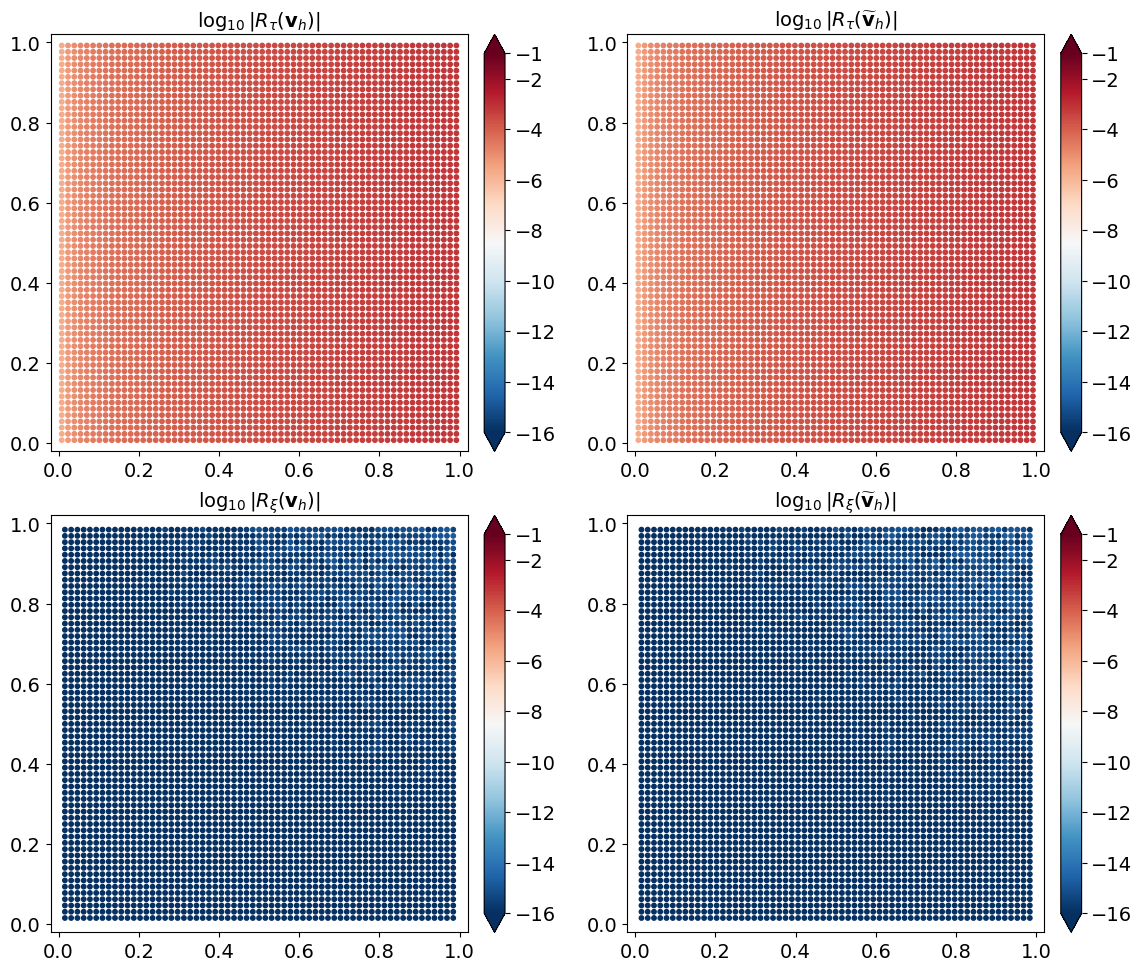

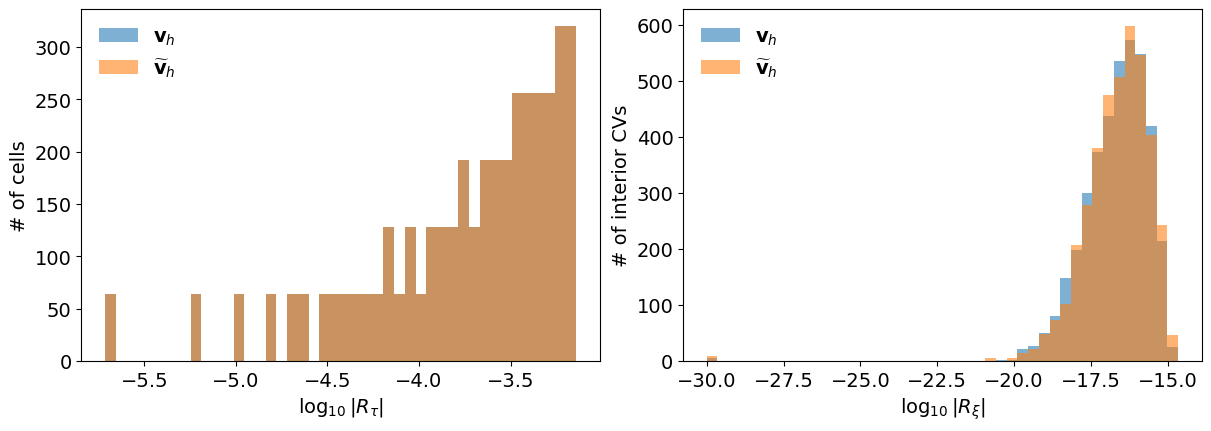

In [19]:
mean_e_cg, med_e_cg, max_e_cg = residual_stats(R_elem_cg)
mean_e_rec, med_e_rec, max_e_rec = residual_stats(R_elem_rec)
mean_cv_cg, med_cv_cg, max_cv_cg = residual_stats(R_cv_cg, interior_ids)
mean_cv_rec, med_cv_rec, max_cv_rec = residual_stats(R_cv_rec, interior_ids)

print("Element-wise residual R_tau")
print(f"  v_h       mean={mean_e_cg:.3e} median={med_e_cg:.3e} max={max_e_cg:.3e}")
print(f"  vtilde_h  mean={mean_e_rec:.3e} median={med_e_rec:.3e} max={max_e_rec:.3e}")
print("Interior control-volume residual R_xi")
print(f"  v_h       mean={mean_cv_cg:.3e} median={med_cv_cg:.3e} max={max_cv_cg:.3e}")
print(f"  vtilde_h  mean={mean_cv_rec:.3e} median={med_cv_rec:.3e} max={max_cv_rec:.3e}")

cent = np.vstack([c["centroid"] for c in rect_demo["cells"]])
xyv = rect_demo["vertices_xy"]
R_LOG_VMIN, R_LOG_VMAX = -16.0, -1.0
R_CBAR_TICKS = np.array([-16, -14, -12, -10, -8, -6, -4, -2, -1], dtype=float)
fig, axes = plt.subplots(2, 2, figsize=(11.5, 9.6), constrained_layout=True)
map_specs = [
    (axes[0, 0], cent, R_elem_cg, r"$\log_{10}|R_\tau(\mathbf{v}_h)|$"),
    (axes[0, 1], cent, R_elem_rec, r"$\log_{10}|R_\tau(\widetilde{\mathbf{v}}_h)|$"),
    (axes[1, 0], xyv[interior_ids], R_cv_cg[interior_ids], r"$\log_{10}|R_\xi(\mathbf{v}_h)|$"),
    (axes[1, 1], xyv[interior_ids], R_cv_rec[interior_ids], r"$\log_{10}|R_\xi(\widetilde{\mathbf{v}}_h)|$"),
]
for ax, xy, R, title in map_specs:
    sc = ax.scatter(
        xy[:, 0], xy[:, 1], c=np.log10(np.abs(R) + 1e-30),
        s=10, cmap="RdBu_r", vmin=R_LOG_VMIN, vmax=R_LOG_VMAX,
    )
    ax.set_aspect("equal")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(title)
    ax.grid(False)
    cbar = fig.colorbar(sc, ax=ax, pad=0.02, extend="both")
    cbar.set_ticks(R_CBAR_TICKS)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), constrained_layout=True)
bins_e = np.linspace(min(np.log10(np.abs(R_elem_cg)+1e-30).min(), np.log10(np.abs(R_elem_rec)+1e-30).min()),
                     max(np.log10(np.abs(R_elem_cg)+1e-30).max(), np.log10(np.abs(R_elem_rec)+1e-30).max()), 45)
axes[0].hist(np.log10(np.abs(R_elem_cg)+1e-30), bins=bins_e, alpha=0.58, label=r"$\mathbf{v}_h$")
axes[0].hist(np.log10(np.abs(R_elem_rec)+1e-30), bins=bins_e, alpha=0.58, label=r"$\widetilde{\mathbf{v}}_h$")
axes[0].set_xlabel(r"$\log_{10}|R_\tau|$")
axes[0].set_ylabel("# of cells")
axes[0].grid(False)
axes[0].legend(frameon=False)

bins_cv = np.linspace(min(np.log10(np.abs(R_cv_cg[interior_ids])+1e-30).min(), np.log10(np.abs(R_cv_rec[interior_ids])+1e-30).min()),
                      max(np.log10(np.abs(R_cv_cg[interior_ids])+1e-30).max(), np.log10(np.abs(R_cv_rec[interior_ids])+1e-30).max()), 45)
axes[1].hist(np.log10(np.abs(R_cv_cg[interior_ids])+1e-30), bins=bins_cv, alpha=0.58, label=r"$\mathbf{v}_h$")
axes[1].hist(np.log10(np.abs(R_cv_rec[interior_ids])+1e-30), bins=bins_cv, alpha=0.58, label=r"$\widetilde{\mathbf{v}}_h$")
axes[1].set_xlabel(r"$\log_{10}|R_\xi|$")
axes[1].set_ylabel("# of interior CVs")
axes[1].grid(False)
axes[1].legend(frameon=False)
plt.show()


In [20]:
# ============================================================
# Sanity check: perturb v_h and recompute R_xi
# ============================================================
# The structured rectangular Q1 case can make R_xi(v_h) nearly exact before
# reconstruction. This check verifies that the CV diagnostic is not hard-coded
# to zero by perturbing the 2D Q1 CG nodal values and recomputing R_xi.
PERTURB_SEED = 11
PERTURB_SCALE = 1.0e-3
rng = np.random.default_rng(PERTURB_SEED)

rect_pert = {
    "cells": [],
    "vertices_xy": rect_demo["vertices_xy"],
    "edge_to_cells": rect_demo["edge_to_cells"],
    "vtc": rect_demo["vtc"],
    "edge_defs": rect_demo["edge_defs"],
    "num_cells": rect_demo["num_cells"],
    "num_vertices": rect_demo["num_vertices"],
}
for cell in rect_demo["cells"]:
    c = dict(cell)
    c["xy"] = cell["xy"].copy()
    c["vids"] = cell["vids"].copy()
    c["centroid"] = cell["centroid"].copy()
    c["uvals"] = cell["uvals"].copy() + PERTURB_SCALE * rng.standard_normal(4)
    rect_pert["cells"].append(c)

# Reuse the physical source_t from the original local flux dictionary. Only
# the flux side is perturbed through rect_pert["cells"][ci]["uvals"].
R_cv_cg_pert = compute_lce_per_cv_rect(rect_pert, lf_demo, use_rec=False)
mean0, med0, max0 = residual_stats(R_cv_cg, interior_ids)
meanp, medp, maxp = residual_stats(R_cv_cg_pert, interior_ids)

print("Sanity check for R_xi(v_h) on the rectangular median-dual CVs")
print(f"  original  mean={mean0:.3e} median={med0:.3e} max={max0:.3e}")
print(f"  perturbed mean={meanp:.3e} median={medp:.3e} max={maxp:.3e}")
print(f"  perturbation scale in 2D nodal pressure = {PERTURB_SCALE:.1e}")


Sanity check for R_xi(v_h) on the rectangular median-dual CVs
  original  mean=1.044e-16 median=3.014e-17 max=1.723e-15
  perturbed mean=2.745e-03 median=2.148e-03 max=1.748e-02
  perturbation scale in 2D nodal pressure = 1.0e-03
